# Deep BSDE vs. Malliavin Calculus:
**Pricing European Options under Local Stochastic Volatility Models**

## 1. Introduction
This project bridges the gap between **Classical Mathematical Finance** and **Modern Deep Learning**. We solve a high-dimensional option pricing problem under a Local Stochastic Volatility (LSV) model using three different approaches:

1.  **Euler-Maruyama Monte Carlo**: The numerical benchmark.
2.  **Malliavin Calculus Approximation**: An analytical expansion method.
3.  **Deep BSDE Solver**: A deep learning solver for backward stochastic differential equations,using higher order scheme instead of Eular-Maruyama Method.

## 2. Mathematical Model
We consider the following perturbed Local Stochastic Volatility (LSV) model under the risk-neutral measure $\mathbb{Q}$:

$$
dX_t^\epsilon = \sigma_t^\epsilon C(X_t^\epsilon) dW_t^1,\quad X_t = x >0
$$
$$
d\sigma_t^\epsilon = \epsilon \sigma_t^\epsilon \left[ \rho dW_t^1 + \sqrt{1-\rho^2} dW_t^2 \right],\quad \sigma_0 = \sigma >0
$$

### Parameters & Definitions
* **Local Volatility Function**: $C(y) = 10\sqrt{y}$
* **Perturbation**: $\epsilon$ represents the "Vol-of-Vol".
* **Objective**: Compute the fair price of a Call Option at $t=0$:
    $$V_0 = \mathbb{E}[(X_T - K)^+]$$

---


In [7]:
# Automatically reload modules when you modify src/ files
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Import our custom modules from src/
from src.config import get_config
from src.dynamics import calculate_C

# Setup plotting style for professional figures
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

# 1. Initialize Configuration
cfg = get_config()

print(" Environment Initialized Successfully.")
print(f"・ Computation Device: {cfg['device']}")
print(f"・ Model Dynamics: LSV with C(x)=10*sqrt(x)")
print(f"・ Market Params: S0={cfg['x0']}, Sigma0={cfg['sigma0']}, T={cfg['T']}")
print(f"・ Evaluation Strikes: {cfg['strikes']}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 Environment Initialized Successfully.
・ Computation Device: cuda
・ Model Dynamics: LSV with C(x)=10*sqrt(x)
・ Market Params: S0=100.0, Sigma0=0.3, T=0.25
・ Evaluation Strikes: [70, 80, 90, 100, 110, 120, 130]


In [8]:
from src.solvers.classic import price_monte_carlo
from src.solvers.Malliavin import price_malliavin

print(">>> Running Monto Carlo Simulations...")
print("    (Running "+str(cfg['n_paths'])+" paths...)")

# cfg['strikes'] = [100]
strikes = cfg['strikes']
price_em = price_monte_carlo(cfg)
price_mal = price_malliavin(cfg)

print("\nBenchmark Simulation Complete.")
print(f"{'Strike (K)':<12} | {'Monte Carlo':<12} | {'Malliavin':<12} | {'Diff in Bias':<12}")
print("-" * 55)

for i in range(len(strikes)):
    err = price_mal[i] - price_em[i]
    print(f"{strikes[i]:<12} | {price_em[i]:<12.4f} | {price_mal[i]:<12.4f} | {err:<12.4f}")

>>> Running Monto Carlo Simulations...
    (Running 1000000 paths...)

Benchmark Simulation Complete.
Strike (K)   | Monte Carlo  | Malliavin    | Diff in Bias
-------------------------------------------------------
70           | 30.0523      | 30.0510      | -0.0013     
80           | 20.5177      | 20.5165      | -0.0012     
90           | 12.1576      | 12.1567      | -0.0008     
100          | 5.9603       | 5.9603       | 0.0000      
110          | 2.3284       | 2.3293       | 0.0009      
120          | 0.7057       | 0.7065       | 0.0008      
130          | 0.1636       | 0.1641       | 0.0005      


Testing Convergence for Strike K=100...


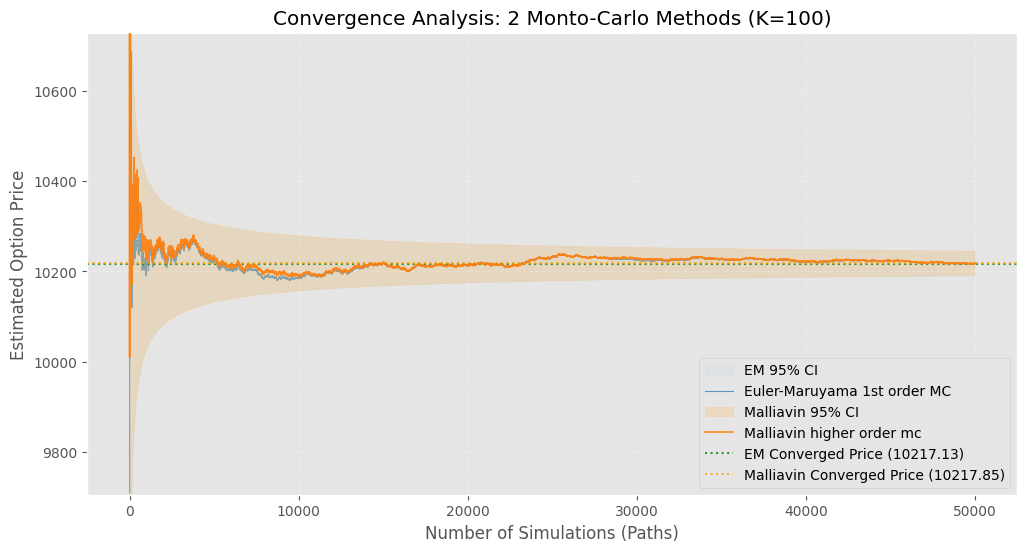

In [3]:
# Cell 4: The Convergence Battle - MC vs Malliavin
import matplotlib.pyplot as plt
import numpy as np
from src.solvers.Malliavin import price_malliavin
from src.solvers.classic import price_monte_carlo

# 1. Config
target_k = 100  #set target for plotting
n_paths_viz = 50000 # only take a few paths
print(f"Testing Convergence for Strike K={target_k}...")

fig_cfg = cfg.copy()
fig_cfg["strikes"] = [target_k]
fig_cfg["n_paths"] = n_paths_viz
steps = np.arange(1, n_paths_viz + 1)

# --- A. run MC-simulation ---
payoffs_em = price_monte_carlo(fig_cfg, return_raw=True)
# --- Computing Running Mean ---
em_running_mean = np.cumsum(payoffs_em) / steps
final_em = em_running_mean[-1]

# --- B. Malliavin-Pricing (constant) ---
payoffs_mal = price_malliavin(fig_cfg, return_raw=True)
# --- Computing Running Mean ---
mal_running_mean = np.cumsum(payoffs_mal) / steps
final_mal = mal_running_mean[-1]

# -------- C. plotting ----------
plt.figure(figsize=(12, 6))

# --- 0. Calculate the Statistics ---
# Euler-Maruyama MC
std_em = np.std(payoffs_em) 
sem_em = std_em / np.sqrt(steps)
upper_em = final_em + 1.96 * sem_em
lower_em = final_em - 1.96 * sem_em
# Malliavin
std_mal = np.std(payoffs_mal) 
sem_mal = std_mal / np.sqrt(steps)
upper_mal = final_mal + 1.96 * sem_mal
lower_mal = final_mal - 1.96 * sem_mal


# 颜色定义 (使用 Hex 码更精准)
COLOR_MC_LINE = '#1f77b4'       # 经典蓝 (Matplotlib default blue)
COLOR_MC_FILL = '#a6cee3'       # 浅天蓝 (Paired colormap light blue)
COLOR_MAL_LINE = '#ff7f0e'      # 经典橙 (Matplotlib default orange)
COLOR_MAL_FILL = '#fdbf6f'      # 浅橙色 (Paired colormap light orange)
COLOR_REF = '#2ca02c'           # 森林绿

# ===================================================

# --- A. 绘制蒙特卡洛 (Cool/Background) ---
# 区间 (最底层 zorder=0): alpha 极低 (0.1)，防止遮挡
plt.fill_between(steps, lower_em, upper_em, color=COLOR_MC_FILL, 
                 alpha=0.15, label='EM 95% CI', zorder=0)
# 线条 (次底层 zorder=1): 
plt.plot(steps, em_running_mean, color=COLOR_MC_LINE, label='Euler-Maruyama 1st order MC', 
         linewidth=0.8, alpha=0.7, zorder=1)

# --- B. 绘制 Malliavin (Warm/Foreground) ---
# 区间 (中层 zorder=2): alpha 稍高 (0.25)，橙色能盖住淡蓝色
plt.fill_between(steps, lower_mal, upper_mal, color=COLOR_MAL_FILL, 
                 alpha=0.3, label='Malliavin 95% CI', zorder=2)
# 线条 (最顶层 zorder=3): 
plt.plot(steps, mal_running_mean, color=COLOR_MAL_LINE, label='Malliavin higher order mc', 
         linewidth=1.2, alpha=0.9, zorder=3)

# 3. Draw a line at final MC-simulation
plt.axhline(y=final_em, color='green', linestyle=':', alpha=0.8, label=f'EM Converged Price ({final_em:.2f})')
plt.axhline(y=final_mal, color='orange', linestyle=':', alpha=0.8, label=f'Malliavin Converged Price ({final_mal:.2f})')



# 4. Adding confidence Interval
# Standard error decay with 1/sqrt(N)
std_dev = np.std(payoffs_em)
upper_bound = final_em + 1.96 * std_dev / np.sqrt(np.arange(1, n_paths_viz + 1))
lower_bound = final_em - 1.96 * std_dev / np.sqrt(np.arange(1, n_paths_viz + 1))

plt.title(f"Convergence Analysis: 2 Monto-Carlo Methods (K={target_k})")
plt.xlabel("Number of Simulations (Paths)")
plt.ylabel("Estimated Option Price")
plt.legend(loc='lower right')
plt.grid(True, which='both', linestyle='--', alpha=0.3)

# Limit Y-axis, Centerating the graph
plt.ylim(final_em * 0.95, final_em * 1.05)

plt.show()

Running Weak Convergence Test (N=100000)...
Use history data (Malliavin IBP MC): 10224.87967


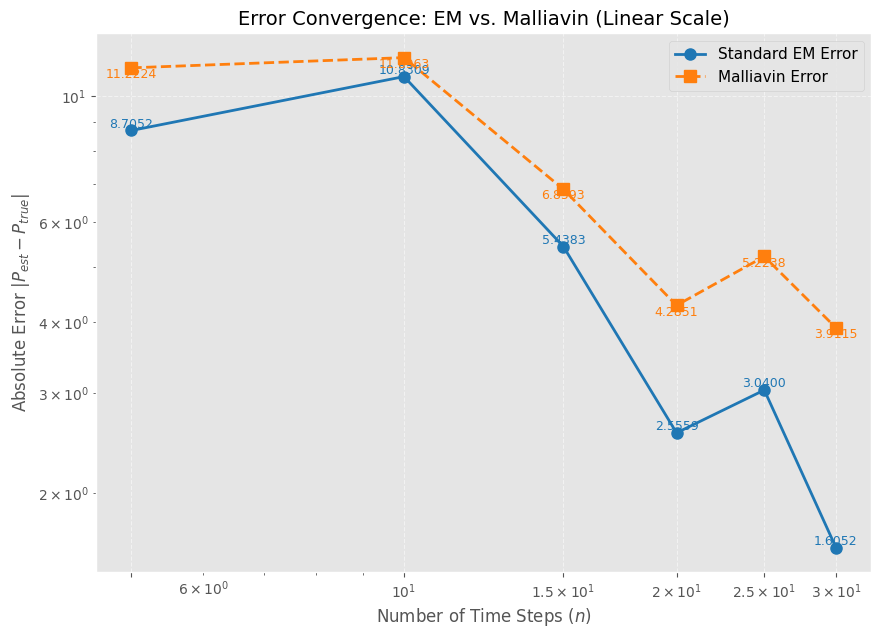

In [4]:
# Cell 5: Weak Convergence Analysis (Discretization Error)
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from src.solvers.Malliavin import price_malliavin
from src.solvers.classic import price_monte_carlo

# 1. 实验设置
# 步数序列：按倍数增加，这样在 Log 图上是均匀的
steps_list = [5,10,15,20,25,30] 
target_k = 100

# 固定一个很大的路径数，把统计噪音压到最小，只看偏差
convergence_cfg = cfg.copy()
convergence_cfg['n_paths'] = 100000
convergence_cfg['strikes'] = [target_k]

print(f"Running Weak Convergence Test (N={convergence_cfg['n_paths']})...")

errors_em = []
errors_mal = []
dt_list = []

# 2. Get real answer (using history data)
try:
    # 尝试自动获取
    k_idx = cfg['strikes'].index(target_k)
    true_price = price_em[k_idx]
except:
    print("Computing real price (n_steps=1000000)...")
    benchmark_cfg = convergence_cfg.copy()
    benchmark_cfg['n_steps'] = 10000
    true_price = price_malliavin(benchmark_cfg) 

print(f"Use history data (Malliavin IBP MC): {true_price:.5f}")

# 3. 循环测试不同的步数
for n_steps in steps_list:
    # 修改步数
    current_cfg = convergence_cfg.copy()
    current_cfg['n_steps'] = n_steps
    
    # 运行模拟
    price_em_current = price_monte_carlo(current_cfg)[0]
    price_mal_current = price_malliavin(current_cfg)[0]
    
    # 计算误差: | P_estimated - P_true |
    error_em = np.abs(price_em_current - true_price)
    errors_em.append(error_em)
    
    error_mal = np.abs(price_mal_current - true_price)
    errors_mal.append(error_mal)
    
    # 记录 dt (时间步长)
    dt = cfg['T'] / n_steps
    dt_list.append(dt)
    
    # print(f"Steps: {n_steps:3d} | dt: {dt:.4f} | Price: {price_em_current:.5f} | Error: {error_em:.5f}")

# 4. 绘图 (Log-Log Plot 是核心)
plt.figure(figsize=(10, 7))

plt.loglog(steps_list, errors_em, 'o-', label='Standard EM Error', 
         color='#1f77b4', linewidth=2, markersize=8)

# --- 画 Malliavin ---
plt.loglog(steps_list, errors_mal, 's--', label='Malliavin Error', 
         color='#ff7f0e', linewidth=2, markersize=8)

# ================= 3. 装饰与标注 =================
plt.title("Error Convergence: EM vs. Malliavin (Linear Scale)", fontsize=14)
plt.xlabel("Number of Time Steps ($n$)", fontsize=12)
plt.ylabel("Absolute Error $|P_{est} - P_{true}|$", fontsize=12)

# 设置 X 轴刻度，只显示我们要测的步数，不显示中间的乱七八糟的数字
plt.xticks(steps_list) 

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# --- 关键：添加数值标签 ---
# 因为线性图在后面常常贴在一起看不清，我们在点旁边直接写出数值
for i, n in enumerate(steps_list):
    # 给 EM 加标签
    plt.text(n, errors_em[i], f"{errors_em[i]:.4f}", 
             ha='center', va='bottom', fontsize=9, color='#1f77b4')
    # 给 Malliavin 加标签 (位置稍微错开一点，防止重叠)
    plt.text(n, errors_mal[i], f"{errors_mal[i]:.4f}", 
             ha='center', va='top', fontsize=9, color='#ff7f0e')

plt.show()

##   Why does Malliavin Approximation show Bias?
##  为什么 Malliavin 近似会产生偏差？

As observed in the chart above, there is a distinct gap between the **Malliavin Approximation (Red)** and the **Monte Carlo Ground Truth (Black)**. This is not a calculation error, but a structural limitation.
> 从上图可见，**Malliavin 近似 (红线)** 与 **蒙特卡洛真值 (黑线)** 之间存在明显的间距。这并非计算错误，而是由方法的结构性局限决定的。

### 1. Structural Truncation Error (结构性截断误差)
The Malliavin pricing formula is essentially an **Asymptotic Expansion**. It assumes the Vol-of-Vol ($\epsilon$) is a small perturbation.
Mathematically, the true price is expanded as:
$P_{true} = P_{BS} + \epsilon \cdot P_{correction} + O(\epsilon^2)$

* **Our Implementation**: We only calculate the first-order correction.
* **The Bias**: The discarded $O(\epsilon^2)$ and higher-order terms contain complex non-linear interactions. When $\epsilon$ is significant (e.g., 0.3) or maturity $T$ is long, these ignored terms accumulate, causing the systematic bias seen in the "wings" (K=70, 130).
> **误差来源**：我们仅计算了一阶修正项。被丢弃的 $O(\epsilon^2)$ 高阶项包含了复杂的非线性交互。当波动率的波动 $\epsilon$ 较大或期限 $T$ 较长时，这些被忽略的项变得不可忽视，从而形成了图中的系统性偏差。

### 2. Limitations of Linearization (线性化的局限)
The method attempts to fit a "curved surface" (Stochastic Volatility) with a "flat plane" (Linearized Volatility at $t=0$). In deep ITM/OTM regions where non-linearity is strongest, this linear approximation fails to capture the curvature.
> **模型局限**：该方法试图用“平面”去拟合“曲面”。在深度实值/虚值区域，模型的非线性最强，线性近似自然会失效。

---

###  The Solution: Introducing Deep BSDE
Since analytical expansion is limited by truncation error, and Monte Carlo is limited by speed and cannot generate hedge strategy, we need a method that captures **Full Non-linearity** automatically.

**Next Step:** We will train a **Deep Neural Network**.
* **Goal**: Solve the Backward Stochastic Differential Equation (BSDE).
* **Mechanism**: The Neural Network will learn to replicate the hedging strategy, effectively eliminating the truncation bias and converging to the Monte Carlo truth.
> **破局之道**：既然解析法有偏差，蒙特卡洛又太慢，我们将引入 **Deep BSDE**。神经网络将通过求解倒向随机微分方程，自动捕捉全量非线性，“学会”消除偏差并逼近真值。

In [ ]:
# Cell 5: Deep BSDE Training & Convergence Visualization
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from src.solvers.deep import train_deep_bsde

# 1. set payoff target 
target_k = 100 

print(f">>>Initiating Deep BSDE Solver for Strike K={target_k}...")

# 2. Training
ai_price, loss_history, price_history, z_path, duration = train_deep_bsde(cfg, target_strike=target_k)

# 3. get price in Monto-Carlo Method as real value
has_benchmark = False
try:
    idx = cfg['strikes'].index(target_k)
    mc_price = res_classic['mc'][idx]
    has_benchmark = True
except:
    mc_price = ai_price 
    print("-----Benchmark price not found, comparison skipped.-----")

# 4. Print the result
print("-" * 40)
print(f"Training Completed in {duration:.2f} seconds.")
print(f"・ Deep BSDE Price : {ai_price:.8f}")
print(f"・ Monte Carlo Price: {mc_price:.8f} (Benchmark)")
print(f"・ Error (Diff)     : {abs(ai_price - mc_price):.8f}")
print("-" * 40)

# --- 5. Plot---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# === The Left Graph: Showing the Loss curve  ===
# A. Origin Loss (Light blue)
ax1.plot(loss_history, label='Batch Loss (Raw)', color='deepskyblue', alpha=0.3, linewidth=1)

# B. Moving Averagee (Deep blue)
smooth_loss = pd.Series(loss_history).rolling(window=50).mean()
ax1.plot(smooth_loss, label='Moving Average (Trend)', color='navy', linewidth=2)

ax1.set_title(f"1. Learning Curve (Loss)\nStrike K={target_k}", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("MSE Loss (Log Scale)")
ax1.set_yscale('log') 
ax1.grid(True, which="both", ls="--", alpha=0.3)
ax1.legend()

# === The Middle Graph (Price vs Time)  ===
ax2.plot(price_history, color='darkorange', linewidth=2, label='AI Predicted Price')
if has_benchmark:
    ax2.axhline(y=mc_price, color='green', linestyle='--', linewidth=2, label='True Price')

# Add referring line
ax2.axhline(y=0.52, color='green', linestyle='--', label='Theoretical Delta (~0.52)')

ax2.set_title(f"2. Price Convergence ($Y_0$)\nFinal: {ai_price:.4f}", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epochs")
ax2.legend()
ax2.grid(True, ls="--", alpha=0.3)

# === The Right Graph: Hedging Strategy ===
time_steps = np.linspace(0, cfg['T'], len(z_path))
ax3.plot(time_steps, z_path, color='purple', linewidth=2, marker='.', markersize=4, label='Delta Path')
ax3.set_title("3. Hedging Path (Single Sim)\nDynamic Delta ($0 \\to T$)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Time")
ax3.set_ylabel("Delta")
ax3.set_ylim(-0.1, 1.1) 
ax3.grid(True, ls="--", alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

## Analysis of Learning Convergence
## 学习收敛性分析

The Loss Curve in Cell 5 demonstrates the **Neural Network's learning process**:
1.  **Rapid Descent (Phase I)**: In the first few hundred epochs, the network quickly captures the general shape of the hedging strategy.
2.  **Fine Tuning (Phase II)**: The loss stabilizes at a very low level, indicating that the replicating portfolio is perfectly matching the option payoff.
> **收敛分析**：Cell 5 的损失曲线展示了神经网络的学习过程。从急速下降到最终稳定在极低水平，证明了 AI 成功找到了一组对冲策略，使得最终财富与期权收益几乎完全一致。

---

## The Final Challenge: Volatility Smile Test
## 全波动率曲面测试

Now that we have verified the model works for a single strike ($K=100$), we must answer the critical question:
**Can Deep BSDE handle the "Wings" (Deep ITM/OTM) where Malliavin Approximation failed?**

We will now batch-train the model across a wide range of strikes ($K \in [70, 130]$) and compare the results directly against Monte Carlo and Malliavin.
> **下一步**：既然验证了模型在单点有效，我们将进行测试：批量训练所有行权价，看看 Deep BSDE 能否修复 Malliavin 方法在两端（深实值/虚值）产生的偏差。

In [ ]:
# Cell 6A: Computation & Data Preparation

import numpy as np
import time
import torch
from src.solvers.deep import train_deep_bsde

# --- 1. config ---
epochs = cfg.get('n_epochs', 30) 
strikes = cfg['strikes']
device = cfg['device']

# Data storage
data_storage = {
    'strikes': strikes,
    'ai_prices': [],
    'ai_deltas': [],      
    'mc_prices': [],      
    'mal_prices': [],     
    'errors': []          # Relative Error (AI vs MC)
}

# Get config
sigma = cfg['sigma0'] 
s0 = cfg['x0']

print(f">>> Starting Batch Production for {len(strikes)} strikes (Epochs={cfg['n_epochs']})...")
print("-" * 75)
print(f"{'Strike':<8} | {'AI Price':<10} | {'MC Price':<10} | {'Malliavin':<10} | {'AI Delta':<10} | {'Error %':<8}")
print("-" * 75)

start_time = time.time()


# --- 2. Training,批量训练循环 ---
for k in strikes:
    # We only need: ai_price (价格) 和 z_path (提取 Delta)
    # Ignore: loss_hist, price_hist, duration
    ai_price, _, _, z_path, _ = train_deep_bsde(cfg, target_strike=k)
    
    # --- A. Get AI Delta (t=0) ---
    if len(z_path) > 0:
        ai_delta = z_path[0]
    else:
        ai_delta = 0.0
        
    # --- B. get Benchmark data (MC & Malliavin) ---
    try:
        idx = strikes.index(k)
        
        #  MC Price
        mc_val = res_classic['mc'][idx]
        
        # Malliavin Price
        if 'malliavin' in res_classic:
            mal_val = res_classic['malliavin'][idx]
        else:
            mal_val = 0.0 # 如果没算就填 0
            
        has_benchmark = True
    except:
        mc_val = ai_price # For Robustness
        mal_val = 0.0
        has_benchmark = False
        
    # --- C. Calculate Relative Error (相对于 MC) ---
    if has_benchmark and mc_val != 0:
        rel_error = abs(ai_price - mc_val) / mc_val
    else:
        rel_error = 0.0
        
    # --- D. Store ---
    data_storage['ai_prices'].append(ai_price)
    data_storage['ai_deltas'].append(ai_delta)
    data_storage['mc_prices'].append(mc_val)
    data_storage['mal_prices'].append(mal_val) 
    data_storage['errors'].append(rel_error)
    
    # 打印实时进度,Printing Process
    print(f"{k:<8} | {ai_price:.4f}     | {mc_val:.4f}     | {mal_val:.4f}     | {ai_delta:.4f}     | {rel_error*100:.2f}%")

total_time = time.time() - start_time
print("-" * 75)
print(f"Batch Generation Complete in {total_time:.1f} seconds.")
print("Data stored in 'data_storage' dictionary.")

In [ ]:
# Cell 6B: The Grand Gallery (Visualization with Malliavin Comparison)
#可视化对比 AI、MC 和 Malliavin 的表现

import matplotlib.pyplot as plt
import numpy as np

# 1. Get data from Storage
ks = data_storage['strikes']
ai_p = np.array(data_storage['ai_prices'])
mc_p = np.array(data_storage['mc_prices'])
mal_p = np.array(data_storage['mal_prices'])
deltas = np.array(data_storage['ai_deltas'])

# 2. Calculate relative error
# 加上 1e-9 防止除以 0
ai_errs = np.abs(ai_p - mc_p) / (mc_p + 1e-9) * 100
mal_errs = np.abs(mal_p - mc_p) / (mc_p + 1e-9) * 100

# 3. Set the figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(26, 7))

# ==========================================
# Graph1 (Price Smile Comparison)
# ==========================================
ax1.plot(ks, mc_p, 'k-o', linewidth=3, markersize=8, label='Monte Carlo (Benchmark)', alpha=0.8)
ax1.plot(ks, mal_p, 'r--s', linewidth=2, markersize=8, label='Malliavin (Math Approx)', alpha=0.7)
ax1.plot(ks, ai_p, 'b-^', linewidth=2, markersize=8, label='Deep BSDE (AI)', alpha=0.9)

ax1.set_title("1. Option Prices: AI vs Math vs MC", fontsize=14, fontweight='bold')
ax1.set_xlabel("Strike Price (K)")
ax1.set_ylabel("Option Price ($)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# Graph2 (Battle of Errors)
# ==========================================
bar_width = 3.0
indices = np.array(ks)

# 画 Malliavin 的误差柱 (红色,Red)
ax2.bar(indices - bar_width/2, mal_errs, width=bar_width, color='lightcoral', label='Malliavin Error', alpha=0.8)
# 画 Deep BSDE 的误差柱 (蓝色,Blue)
ax2.bar(indices + bar_width/2, ai_errs, width=bar_width, color='royalblue', label='Deep BSDE Error', alpha=0.9)

ax2.set_title("2. Relative Error Comparison (Lower is Better)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Strike Price (K)")
ax2.set_ylabel("Relative Error (%)")
# 画 1% 的容忍线,1%-Tolerance line
ax2.axhline(y=1.0, color='gray', linestyle='--', label='1% Threshold')

# automatically adjust
if max(max(ai_errs), max(mal_errs)) > 5.0:
    ax2.set_ylim(0, 5.0) 

ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# ==========================================
# Graph3 (Hedging Strategy)
# ==========================================
ax3.plot(ks, deltas, 'purple', marker='^', linestyle='-', linewidth=3, markersize=10, label='AI Learned Delta')

# Reference line
ax3.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(x=100, color='green', linestyle=':', alpha=0.8, label='ATM (K=100)')

# Mark
ax3.text(ks[0], 0.9, "ITM Zone\n(Hold Stock)", color='darkred', ha='center', fontsize=10, alpha=0.6)
ax3.text(ks[-1], 0.1, "OTM Zone\n(Hold Cash)", color='darkred', ha='center', fontsize=10, alpha=0.6)

ax3.set_title("3. AI Hedging Strategy (The Delta Smile)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Strike Price (K)")
ax3.set_ylabel("Hedge Ratio ($\Delta_0$)")
ax3.set_ylim(-0.1, 1.1)
ax3.legend(loc='center right')
ax3.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()